# Final Preprocessing Noflip25, clustering, and co

This is the final ipynb, showing what preprocessing was done and what parameters were used for clustering.

In [1]:
import numpy as np
import os
import sklearn.preprocessing
from umap import umap_ as umap
import wavemap_paper
%matplotlib widget
import matplotlib.pyplot as plt 
from matplotlib import cm
from matplotlib import pyplot as plt
import random
from wavemap_paper.helper_functions import RAND_STATE, set_rand_state, plot_inverse_mapping
import networkx as nx
import cylouvain
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import mplcursors

from cluster import *


# get working directory
os.chdir("d:\\MasterThesis")
os.getcwd()

'd:\\MasterThesis'

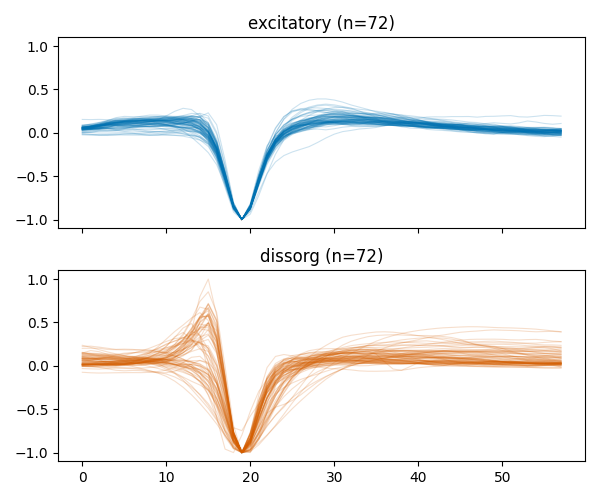

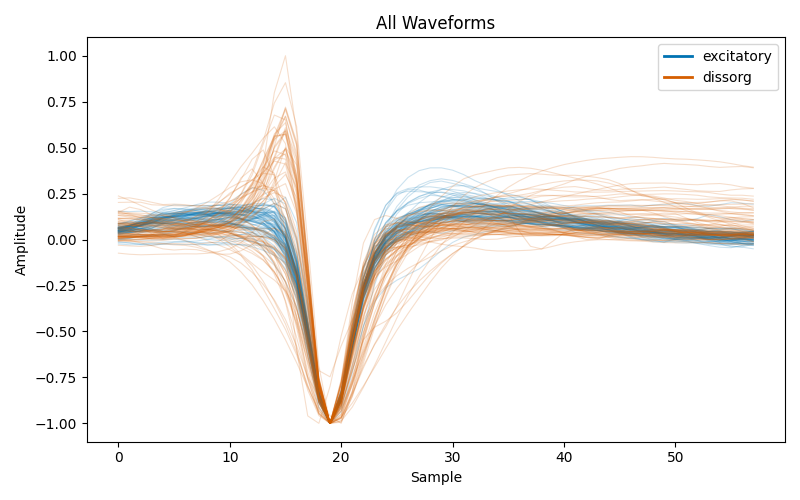

In [2]:
# Load the preprocessed noflip25 data

data_path_dissorg = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_dissorg_noflip25.csv"
data_path_excit = "d:\\MasterThesis\\NEW_BRW_average_waveforms_filtered_excit_noflip25.csv"

data_list = [data_path_excit, data_path_dissorg] 
data_labels = ['excitatory', 'dissorg']   

# Load the data
all_wf, all_labels = load_and_stack_waveforms(pathlist=data_list, labellist=data_labels, plot=True)

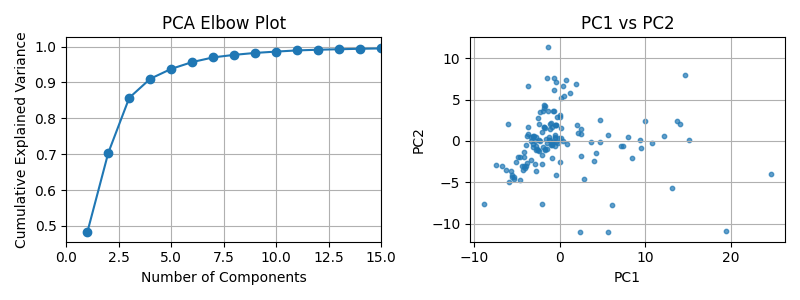

Components that explain 90% of variance: 4


In [3]:
# Run PCA

X_pca, pca, nc = run_pca(all_wf, n_exp_var = 0.9,plot = True)
print("Components that explain 90% of variance:", nc)

adjacency_matrix will return a scipy.sparse array instead of a matrix in Networkx 3.0.


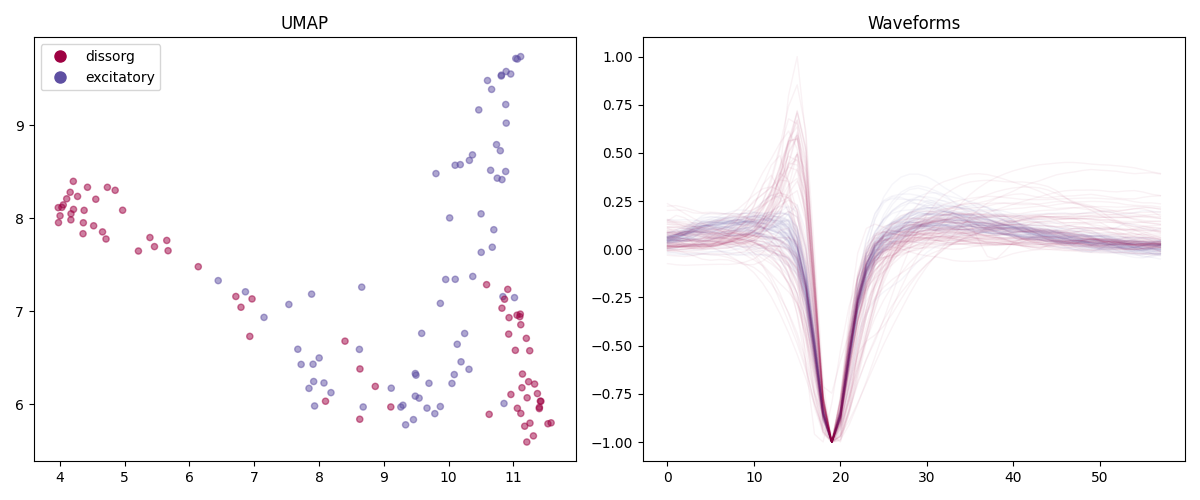

In [13]:
# Set seed
seed = 43
np.random.seed(seed)    # NumPy
random.seed(seed)       # Python built-in random module
set_rand_state(RAND_STATE)

# Run UMAP
umap_df, clustering_solution = run_umap(all_wf, all_labels, n_nb=15, min_d=0.1, n_comps=4, resolution = 3, metric='euclidean', random_state=RAND_STATE)

# Plot UMAP with dataset labels
interactive_umap_plot(umap_df, cmap_name="Spectral")

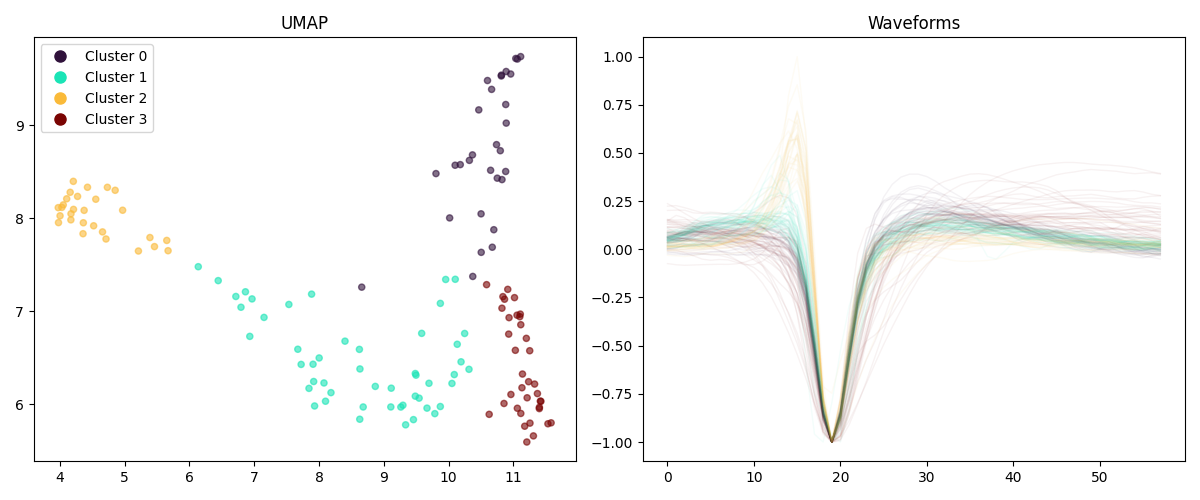

In [14]:
# Plot UMAP with cluster labels
interactive_umap_clusters(umap_df)

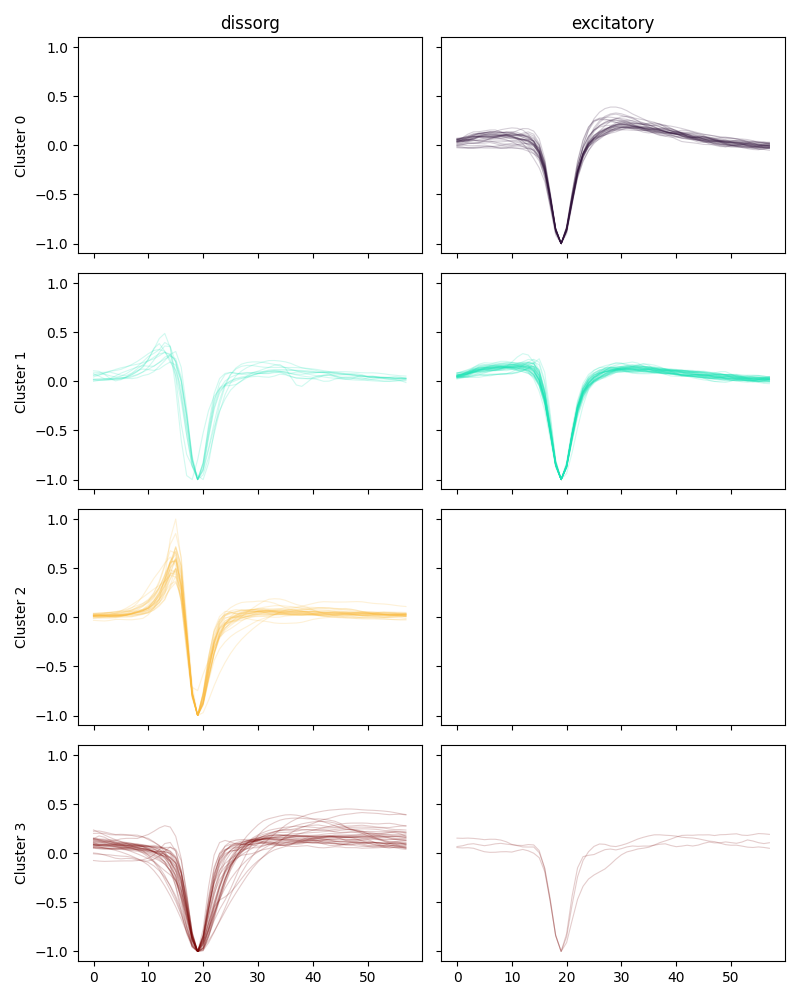

In [15]:
plot_cluster_waveforms(umap_df,plot_mean=False,alpha=0.2, figsize_per_panel=(4, 2.5))